In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [4]:
df = pd.read_csv('airquality.csv')

In [5]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Katihar,"Mirchaibari, Katihar - BSPCB",18-02-2026 16:00:00,25.560083,87.553265,PM10,52.0,100.0,80.0
1,India,Bihar,Katihar,"Mirchaibari, Katihar - BSPCB",18-02-2026 16:00:00,25.560083,87.553265,NH3,1.0,1.0,1.0
2,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",18-02-2026 16:00:00,26.088130,87.938403,PM2.5,47.0,200.0,112.0
3,India,Bihar,Manguraha,"Forest Rest House, Manguraha - BSPCB",18-02-2026 16:00:00,27.308328,84.531742,PM2.5,70.0,207.0,105.0
4,India,Bihar,Manguraha,"Forest Rest House, Manguraha - BSPCB",18-02-2026 16:00:00,27.308328,84.531742,NH3,1.0,2.0,1.0


In [6]:
df.shape

(3312, 11)

In [7]:
df.skew(numeric_only=True)

latitude        -0.596907
longitude        0.992982
pollutant_min    1.562904
pollutant_max    1.901717
pollutant_avg    1.815447
dtype: float64

<Axes: ylabel='pollutant_avg'>

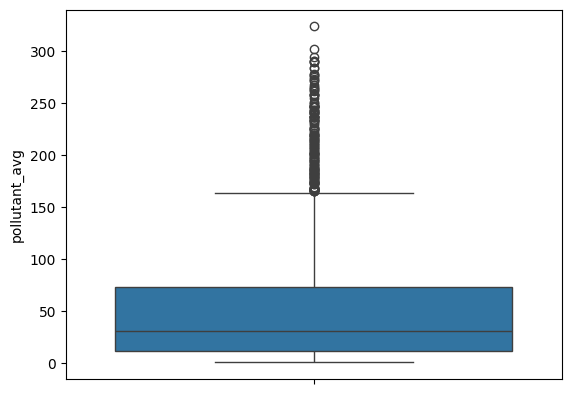

In [8]:

sb.boxplot(df['pollutant_avg'])

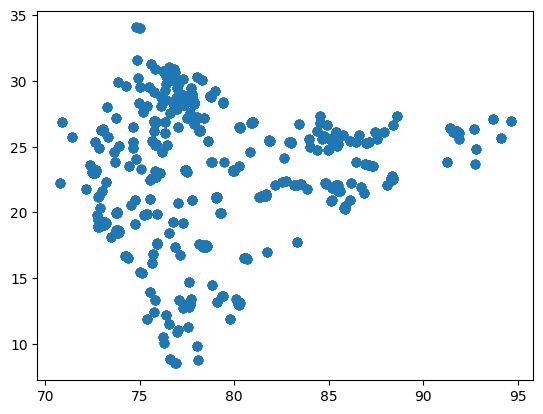

In [9]:
plt.scatter(df['longitude'], df['latitude'])
plt.show()

In [10]:
df['pollutant_avg'] = pd.to_numeric(df['pollutant_avg'], errors='coerce')
df = df.dropna(subset=['pollutant_avg'])


In [11]:
df['last_update'] = pd.to_datetime(df['last_update'], format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['last_update'].dt.hour
df['month'] = df['last_update'].dt.month

In [12]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,hour,month
0,India,Bihar,Katihar,"Mirchaibari, Katihar - BSPCB",2026-02-18 16:00:00,25.560083,87.553265,PM10,52.0,100.0,80.0,16,2
1,India,Bihar,Katihar,"Mirchaibari, Katihar - BSPCB",2026-02-18 16:00:00,25.560083,87.553265,NH3,1.0,1.0,1.0,16,2
2,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",2026-02-18 16:00:00,26.088130,87.938403,PM2.5,47.0,200.0,112.0,16,2
3,India,Bihar,Manguraha,"Forest Rest House, Manguraha - BSPCB",2026-02-18 16:00:00,27.308328,84.531742,PM2.5,70.0,207.0,105.0,16,2
4,India,Bihar,Manguraha,"Forest Rest House, Manguraha - BSPCB",2026-02-18 16:00:00,27.308328,84.531742,NH3,1.0,2.0,1.0,16,2


In [13]:
# remove outliers 
q1 = df.pollutant_avg.quantile(0.75)
q3 = df.pollutant_avg.quantile(0.15)

IQR = q3 - q1

In [14]:
lowerlimit = q1 - 1.5 * IQR
upperlimit = q1 + 1.5 * IQR

In [15]:
lowerlimit, upperlimit

(np.float64(170.5), np.float64(-24.5))

In [16]:
df.clean  = df[(df.pollutant_avg   >= lowerlimit)  & (df.pollutant_avg <= upperlimit)]

C:\Users\Gagan\AppData\Local\Temp\ipykernel_4272\2730204641.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.clean  = df[(df.pollutant_avg   >= lowerlimit)  & (df.pollutant_avg <= upperlimit)]


In [17]:
df = df.drop(['country', 
              'station', 
              'last_update', 
              'pollutant_min', 
              'pollutant_max'], axis=1)


In [27]:
df = pd.get_dummies(df, columns=['state', 'city', 'pollutant_id'], drop_first=True)

In [28]:
x = df.drop('pollutant_avg', axis=1)
y = df['pollutant_avg']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [31]:
x_train.shape,y_train.shape

((2523, 290), (2523,))

In [32]:
print(x.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [35]:
rdf = RandomForestRegressor(n_estimators=200,random_state=42)
rdf.fit(x_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
print("Train Score:", rdf.score(x_train, y_train))
print("Test Score:", rdf.score(x_test, y_test))


Train Score: 0.958876755896672
Test Score: 0.7230104644423683


In [39]:
import joblib

joblib.dump(rdf,"models/airquality_model.pkl")
joblib.dump(x_train.columns.tolist(), "models/model_columns.pkl")

['models/model_columns.pkl']